In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import *
from numpy import newaxis

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 15)

In [2]:
df = pd.read_csv('data.csv')

In [3]:
def _standardize_datetime_str(dt_str):
    """Helper: Convert datetime string to YYYY-MM-DD HH:MM:SS format."""
    try:
        if len(dt_str.split(':')) == 3:
            dt = pd.to_datetime(dt_str, format='%Y-%m-%d %H:%M:%S')
        else:
            dt = pd.to_datetime(dt_str, format='%Y-%m-%d %H:%M')
        return dt.strftime('%Y-%m-%d %H:%M:%S')
    except:
        return pd.to_datetime(dt_str).strftime('%Y-%m-%d %H:%M:%S')


def standardize_datetime_column(df, datetime_col='DateTime', verbose=True):
    """
    Pipeline Step 1: Standardize DateTime format to YYYY-MM-DD HH:MM:SS.
    
    Usage with .pipe():
        df.pipe(standardize_datetime_column)
    """
    if verbose:
        print("="*60)
        print("[1/5] Standardizing DateTime column")
        print("="*60)
    
    return (df
            .assign(**{datetime_col: lambda x: x[datetime_col].apply(_standardize_datetime_str)})
            .pipe(lambda df: df if not verbose else 
                  (print(f"✓ Standardized {len(df):,} rows") or df))
           )


def remove_duplicate_observations(df, product_col='Product_Number', datetime_col='DateTime', verbose=True):
    """
    Pipeline Step 2: Remove duplicates, keeping latest observation per Product-Date.
    
    For each Product on the same date, keeps only the latest time.
    
    Usage with .pipe():
        df.pipe(remove_duplicate_observations)
    """
    if verbose:
        print("\n" + "="*60)
        print("[2/5] Removing duplicate observations")
        print("="*60)
        rows_before = len(df)
    
    result = (df
              .assign(_datetime_temp=lambda x: pd.to_datetime(x[datetime_col]))
              .assign(_date_temp=lambda x: x['_datetime_temp'].dt.date)
              .sort_values([product_col, '_date_temp', '_datetime_temp'])
              .drop_duplicates(subset=[product_col, '_date_temp'], keep='last')
              .drop(columns=['_datetime_temp', '_date_temp'])
              .reset_index(drop=True)
             )
    
    if verbose:
        rows_removed = rows_before - len(result)
        print(f"✓ Before: {rows_before:,} rows")
        print(f"✓ After:  {len(result):,} rows")
        print(f"✓ Removed: {rows_removed:,} rows ({100*rows_removed/rows_before:.2f}%)")
    
    return result


def filter_products_by_observation_count(df, product_col='Product_Number', required_count=95, verbose=True):
    """
    Pipeline Step 3: Filter products with exact required observation count.
    
    Removes products that don't have exactly the required number of observations.
    """
    if verbose:
        print("\n" + "="*60)
        print(f"[3/5] Filtering products with {required_count} observations")
        print("="*60)
        products_before = df[product_col].nunique()
        rows_before = len(df)
    
    # Count observations per product
    product_counts = df.groupby(product_col).size()
    
    # Get products with required count
    valid_products = product_counts[product_counts == required_count].index
    
    # Filter dataframe
    result = (df
              .loc[lambda x: x[product_col].isin(valid_products)]
              .reset_index(drop=True)
             )
    
    if verbose:
        products_removed = products_before - result[product_col].nunique()
        rows_removed = rows_before - len(result)
        
        print(f"✓ Products before: {products_before:,}")
        print(f"✓ Products after:  {result[product_col].nunique():,}")
        print(f"✓ Products removed: {products_removed:,}")
        print(f"✓ Rows removed: {rows_removed:,}")
        
        # Show distribution of observation counts
        invalid_counts = product_counts[product_counts != required_count]
        if len(invalid_counts) > 0:
            print(f"\n✓ Removed products had observation counts:")
            for count, num_products in invalid_counts.value_counts().sort_index().items():
                print(f"  - {num_products} product(s) with {count} observations")
    
    return result


def create_sliding_window_dataset(df, product_col='Product_Number', verbose=True):
    """
    Pipeline Step 4: Create sliding window dataset by aligning date-related columns.
    
    Applies shift() method to align T, T+1, T+2, T+3, T+4 columns to the same row.
    Removes the first 4 rows per product (contaminated by previous product data).
    
    The dataset has 3 groups of date-related columns (15 total):
    - T~T+4일 예정 수주량 (columns 1-5)
    - 작년 T~T+4일 예정 수주량 (columns 6-10)  
    - T~T+4일 예상 수주량 (columns 11-15)
    
    Each column is shifted by (index % 5) to align dates.
    """
    if verbose:
        print("\n" + "="*60)
        print("[4/5] Creating sliding window dataset")
        print("="*60)
        rows_before = len(df)
    
    result = df.copy()
    
    # Get all column names
    columns_list = result.columns.tolist()
    
    # Date-related columns start at index 1 (after Product_Number)
    # Total 15 columns: indices 1-15
    date_columns_indices = list(range(1, 16))
    
    if verbose:
        print(f"✓ Applying shift to {len(date_columns_indices)} date-related columns")
    
    # Apply shift to each date-related column
    for i in range(15):
        col_idx = i + 1  # Column index in the dataframe
        col_name = columns_list[col_idx]
        shift_amount = i % 5  # Shift by remainder of i/5
        
        if shift_amount > 0:
            result[col_name] = result[col_name].shift(shift_amount)
    
    # Remove first 4 rows for each product (contaminated by shift)
    # Group by product and drop first 4 rows of each group
    result = (result
              .groupby(product_col, group_keys=False)
              .apply(lambda x: x.iloc[4:])
              .reset_index(drop=True)
             )
    
    # Rename columns to reflect aligned dates (all are now "T일" perspective)
    column_mapping = {
        'T일 예정 수주량': 'T일 예정 수주량',
        'T+1일 예정 수주량': 'T-1일 예정 수주량', 
        'T+2일 예정 수주량': 'T-2일 예정 수주량',
        'T+3일 예정 수주량': 'T-3일 예정 수주량',
        'T+4일 예정 수주량': 'T-4일 예정 수주량',
        '작년 T일 예정 수주량': '작년 T일 예정 수주량',
        '작년 T+1일 예정 수주량': '작년 T-1일 예정 수주량',
        '작년 T+2일 예정 수주량': '작년 T-2일 예정 수주량', 
        '작년 T+3일 예정 수주량': '작년 T-3일 예정 수주량',
        '작년 T+4일 예정 수주량': '작년 T-4일 예정 수주량',
        'T일 예상 수주량': 'T일 예상 수주량',
        'T+1일 예상 수주량': 'T-1일 예상 수주량',
        'T+2일 예상 수주량': 'T-2일 예상 수주량',
        'T+3일 예상 수주량': 'T-3일 예상 수주량',
        'T+4일 예상 수주량': 'T-4일 예상 수주량'
    }
    
    result = result.rename(columns=column_mapping)
    
    if verbose:
        rows_removed = rows_before - len(result)
        print(f"✓ Before: {rows_before:,} rows")
        print(f"✓ After:  {len(result):,} rows")
        print(f"✓ Removed: {rows_removed:,} rows (first 4 per product)")
        print(f"✓ Columns renamed to align with T일 perspective")
    
    return result


def encode_cyclical_dow(df, dow_col='DoW', drop_original=True, verbose=True):
    """
    Pipeline Step 5: Encode day of week as cyclical features using sin/cos transformation.
    
    Converts categorical DoW into two continuous features that preserve cyclical nature:
    - DoW_sin: sin(2π * day_number / 7)
    - DoW_cos: cos(2π * day_number / 7)
    
    This ensures Monday (0) and Sunday (6) are close in feature space.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    dow_col : str, default='DoW'
        Name of the day of week column
    drop_original : bool, default=True
        Whether to drop the original DoW column
    verbose : bool, default=True
        If True, print encoding information
    
    Returns:
    --------
    pd.DataFrame : DataFrame with DoW_sin and DoW_cos features
    
    Usage with .pipe():
        df.pipe(encode_cyclical_dow)
    """
    if verbose:
        print("\n" + "="*60)
        print("[5/5] Encoding Day of Week as cyclical features")
        print("="*60)
    
    result = df.copy()
    
    # Map day names to numbers (0-6)
    dow_mapping = {
        'Monday': 0,
        'Tuesday': 1,
        'Wednesday': 2,
        'Thursday': 3,
        'Friday': 4,
        'Saturday': 5,
        'Sunday': 6
    }
    
    # Create numeric day column
    result['_dow_numeric'] = result[dow_col].map(dow_mapping)
    
    # Create cyclical features
    result['DoW_sin'] = np.sin(2 * np.pi * result['_dow_numeric'] / 7)
    result['DoW_cos'] = np.cos(2 * np.pi * result['_dow_numeric'] / 7)
    
    # Drop temporary column
    result = result.drop(columns=['_dow_numeric'])
    
    # Drop original DoW column if requested
    if drop_original:
        result = result.drop(columns=[dow_col])
        if verbose:
            print(f"✓ Created DoW_sin and DoW_cos features")
            print(f"✓ Dropped original '{dow_col}' column")
    else:
        if verbose:
            print(f"✓ Created DoW_sin and DoW_cos features")
            print(f"✓ Kept original '{dow_col}' column")
    
    if verbose:
        print(f"✓ Sample values:")
        print(f"  Monday    -> sin={np.sin(2*np.pi*0/7):.3f}, cos={np.cos(2*np.pi*0/7):.3f}")
        print(f"  Wednesday -> sin={np.sin(2*np.pi*2/7):.3f}, cos={np.cos(2*np.pi*2/7):.3f}")
        print(f"  Friday    -> sin={np.sin(2*np.pi*4/7):.3f}, cos={np.cos(2*np.pi*4/7):.3f}")
        print(f"  Sunday    -> sin={np.sin(2*np.pi*6/7):.3f}, cos={np.cos(2*np.pi*6/7):.3f}")
    
    return result

In [4]:
# ============================================================
# Apply Preprocessing Pipeline
# ============================================================

df = (df
      .pipe(standardize_datetime_column, datetime_col='DateTime', verbose=True)
      .pipe(remove_duplicate_observations, product_col='Product_Number', datetime_col='DateTime', verbose=True)
      .pipe(filter_products_by_observation_count, product_col='Product_Number', required_count=95, verbose=True)
      .pipe(create_sliding_window_dataset, product_col='Product_Number', verbose=True)
      .pipe(encode_cyclical_dow, dow_col='DoW', drop_original=True, verbose=True)
     )

print("\n" + "="*60)
print("✓ Preprocessing Pipeline Complete!")
print("="*60)


[1/5] Standardizing DateTime column
✓ Standardized 34,617 rows

[2/5] Removing duplicate observations
✓ Before: 34,617 rows
✓ After:  10,624 rows
✓ Removed: 23,993 rows (69.31%)

[3/5] Filtering products with 95 observations
✓ Products before: 117
✓ Products after:  102
✓ Products removed: 15
✓ Rows removed: 934

✓ Removed products had observation counts:
  - 1 product(s) with 28 observations
  - 1 product(s) with 30 observations
  - 1 product(s) with 39 observations
  - 1 product(s) with 45 observations
  - 1 product(s) with 46 observations
  - 2 product(s) with 64 observations
  - 1 product(s) with 67 observations
  - 1 product(s) with 69 observations
  - 3 product(s) with 75 observations
  - 1 product(s) with 79 observations
  - 2 product(s) with 89 observations

[4/5] Creating sliding window dataset
✓ Applying shift to 15 date-related columns
✓ Before: 9,690 rows
✓ After:  9,282 rows
✓ Removed: 408 rows (first 4 per product)
✓ Columns renamed to align with T일 perspective

[5/5] Enc

In [5]:
# Verify final preprocessed dataset
print("="*60)
print("Final Preprocessed Dataset Summary")
print("="*60)
print(f"\n✓ Shape: {df.shape}")
print(f"✓ Products: {df['Product_Number'].nunique()}")
print(f"✓ Observations per product: {df.groupby('Product_Number').size().unique()}")

print(f"\n✓ Columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n✓ First few rows:")
df.head()

Final Preprocessed Dataset Summary

✓ Shape: (9282, 21)
✓ Products: 102
✓ Observations per product: [91]

✓ Columns (21):
   1. Product_Number
   2. T일 예정 수주량
   3. T-1일 예정 수주량
   4. T-2일 예정 수주량
   5. T-3일 예정 수주량
   6. T-4일 예정 수주량
   7. 작년 T일 예정 수주량
   8. 작년 T-1일 예정 수주량
   9. 작년 T-2일 예정 수주량
  10. 작년 T-3일 예정 수주량
  11. 작년 T-4일 예정 수주량
  12. T일 예상 수주량
  13. T-1일 예상 수주량
  14. T-2일 예상 수주량
  15. T-3일 예상 수주량
  16. T-4일 예상 수주량
  17. DateTime
  18. Temperature
  19. Humidity
  20. DoW_sin
  21. DoW_cos

✓ First few rows:


,Product_Number,T일 예정 수주량,T-1일 예정 수주량,T-2일 예정 수주량,T-3일 예정 수주량,T-4일 예정 수주량,작년 T일 예정 수주량,...,T-3일 예상 수주량,T-4일 예상 수주량,DateTime,Temperature,Humidity,DoW_sin,DoW_cos
0,Product_86,632,558.0,526.0,555.0,532.0,0,...,904.0,877.0,2022-01-30 06:32:00,9.106250,17.952750,-0.781831,0.623490
1,Product_86,632,0.0,0.0,0.0,0.0,0,...,926.0,863.0,2022-01-31 07:13:00,9.184500,14.939750,0.000000,1.000000
2,Product_86,632,0.0,0.0,0.0,0.0,0,...,641.0,969.0,2022-02-01 06:30:00,8.190541,19.415135,0.781831,0.623490
3,Product_86,632,0.0,0.0,0.0,449.0,0,...,480.0,571.0,2022-02-02 06:29:00,9.003851,24.231491,0.974928,-0.222521
4,Product_86,632,0.0,0.0,0.0,0.0,0,...,480.0,344.0,2022-02-03 06:31:00,9.169762,18.761905,0.433884,-0.900969


In [6]:
# Save preprocessed dataset
output_file = 'data_preprocessed.csv'
df.to_csv(output_file, index=False)

print(f"✓ Preprocessed data saved to: {output_file}")
print(f"✓ File contains {len(df):,} rows and {len(df.columns)} columns")

✓ Preprocessed data saved to: data_preprocessed.csv
✓ File contains 9,282 rows and 21 columns


Cyclical Day of Week Encoding Visualization

✓ Unique cyclical encodings (7 days):
  DoW_sin   DoW_cos
-0.974928 -0.222521
-0.781831  0.623490
-0.433884 -0.900969
 0.000000  1.000000
 0.433884 -0.900969
 0.781831  0.623490
 0.974928 -0.222521


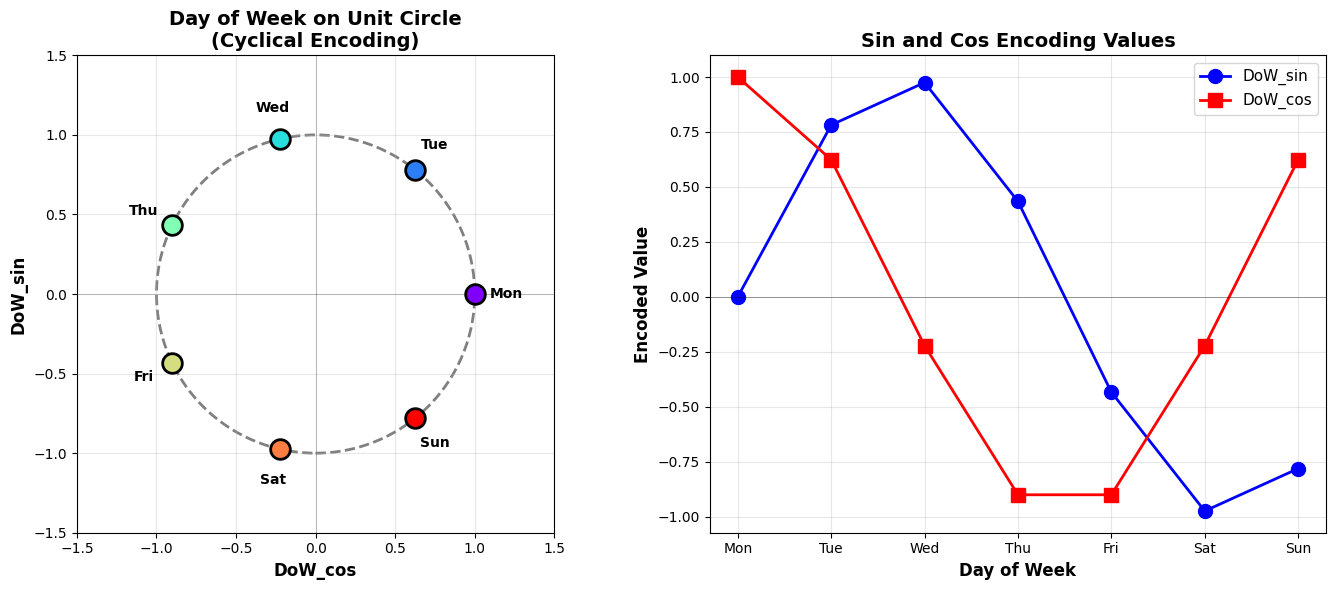


✓ Key properties of cyclical encoding:
  • Monday and Sunday are close in feature space
  • Distance between adjacent days is consistent
  • No artificial ordering (unlike 0,1,2,3,4,5,6)
  • Both features needed to uniquely identify each day


In [7]:
# Visualize cyclical encoding
print("="*60)
print("Cyclical Day of Week Encoding Visualization")
print("="*60)

# Show unique DoW_sin and DoW_cos values
dow_features = df[['DoW_sin', 'DoW_cos']].drop_duplicates().sort_values('DoW_sin')
print(f"\n✓ Unique cyclical encodings (7 days):")
print(dow_features.to_string(index=False))

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Unit circle visualization
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
angles = [2 * np.pi * i / 7 for i in range(7)]
x = [np.cos(angle) for angle in angles]
y = [np.sin(angle) for angle in angles]

# Draw unit circle
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=2)
axes[0].add_patch(circle)

# Plot days on circle
colors = plt.cm.rainbow(np.linspace(0, 1, 7))
for i, (xi, yi, day) in enumerate(zip(x, y, days)):
    axes[0].scatter(xi, yi, s=200, c=[colors[i]], edgecolors='black', linewidth=2, zorder=3)
    # Add labels slightly outside the circle
    offset = 1.2
    axes[0].text(xi*offset, yi*offset, day, ha='center', va='center', 
                fontsize=10, fontweight='bold')

axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_aspect('equal')
axes[0].axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
axes[0].axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
axes[0].set_xlabel('DoW_cos', fontsize=12, fontweight='bold')
axes[0].set_ylabel('DoW_sin', fontsize=12, fontweight='bold')
axes[0].set_title('Day of Week on Unit Circle\n(Cyclical Encoding)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Sin and Cos waves
day_nums = list(range(7))
axes[1].plot(day_nums, [np.sin(2*np.pi*i/7) for i in day_nums], 
            'o-', linewidth=2, markersize=10, label='DoW_sin', color='blue')
axes[1].plot(day_nums, [np.cos(2*np.pi*i/7) for i in day_nums], 
            's-', linewidth=2, markersize=10, label='DoW_cos', color='red')
axes[1].set_xticks(day_nums)
axes[1].set_xticklabels(days)
axes[1].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Encoded Value', fontsize=12, fontweight='bold')
axes[1].set_title('Sin and Cos Encoding Values', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n✓ Key properties of cyclical encoding:")
print(f"  • Monday and Sunday are close in feature space")
print(f"  • Distance between adjacent days is consistent")
print(f"  • No artificial ordering (unlike 0,1,2,3,4,5,6)")
print(f"  • Both features needed to uniquely identify each day")
